# Distributed Systems: Core Concepts

Imagine you and a friend each run a lemonade stand on opposite sides of town,
and you've promised customers a single, shared "stands remaining stock"
number. Easy, if you're standing next to each other — you just look at the
same pitcher. But you're not. You're a mile apart, and the only way to tell
each other anything is by texting, and texts sometimes arrive late, arrive
out of order, or don't arrive at all.

Now a customer texts you: "how much lemonade is left?" You don't actually
know — your friend might have sold three cups in the last minute and you
haven't heard about it yet. Do you answer with a number you know is possibly
stale, or do you refuse to answer until you've confirmed with your friend
(which might take a while, or might never resolve if your friend's phone
died)? **That tension — answer now with maybe-wrong information, or wait and
maybe never answer — is, in miniature, the entire subject of this
tutorial.**

A **distributed system** is any system made of multiple independent
computers (we'll call them **nodes**) that coordinate over a network to look,
from the outside, like one coherent system. Almost everything you use day to
day is one: a bank's account balance replicated across data centers, a
multiplayer game's shared world state, DNS, a shopping cart that has to
survive one server crashing mid-checkout. Distributed systems are not just
"a single-computer program, but bigger" — new failure modes show up that
have no equivalent on one machine, and they force real, unavoidable
trade-offs.

By the end of this tutorial you will be able to:

- Explain *why* distributed systems are fundamentally harder than
  single-node programs, with a concrete story for each reason.
- State the **CAP theorem** and demonstrate, in a runnable simulation, the
  live choice a system is forced to make during a network partition.
- Implement **Lamport timestamps** and **vector clocks** to order — or
  correctly detect as unordered — events happening on different machines.
- Explain why distributed systems need **consensus**, and implement a
  simplified **Raft leader election** that runs multiple simulated nodes to
  an actual, correct leader.
- Implement **consistent hashing** and show, with real numbers, why it beats
  naive hashing when a cluster is resized.

Everything here runs as a *simulation* in plain Python — no real network,
no multiple machines required. We use `threading` and message queues with
artificially injected delay/loss to stand in for a real, unreliable
network. That's a deliberate choice: it makes every failure mode
reproducible and inspectable, which a real network is not.

## 1. The idea, intuitively: why is this hard?

On a single computer, you get several guarantees for free that you stop
getting the moment you add a second machine:

1. **A shared clock.** One CPU has one clock. Two computers each have their
   own physical clock, and those clocks drift — by milliseconds to seconds
   over time, even with NTP synchronization. So "did event A happen before
   event B?" stops having an obvious answer when A and B occurred on
   *different* machines.
2. **Shared memory.** On one machine, if thread A writes a variable, thread
   B can read it immediately (modulo cache/memory-ordering subtleties). Two
   machines have no shared memory — the *only* way for node B to learn what
   node A did is to receive a message about it, and that message travels
   over an unreliable network.
3. **All-or-nothing failure.** A single-machine program either is running or
   it has crashed — there's no in-between state you have to design around.
   A distributed system can suffer **partial failure**: node A is up, node B
   is down, and node C *looks* down to A (no response) but is actually up
   and just slow, or is up but the network between A and C is what failed.
   From A's point of view, "no response from C" is ambiguous between "C
   crashed," "C is just slow," and "the network dropped my message" — and A
   frequently cannot tell which.

**Concrete scenario.** Say a bank replicates your account balance across two
data centers, East and West, so that a data-center outage doesn't take the
bank offline. You withdraw \$100 at an ATM connected to East. East debits
your balance and tries to tell West about it — but the network link between
East and West is briefly down. Ten seconds later, someone uses your card at
a store whose payment terminal talks to West. West still thinks you have
your original balance, because it never heard about the ATM withdrawal. Has
the bank made an error? Not exactly — West made a *locally* reasonable
decision (trust the balance it has) under a constraint no single-machine
system ever has to face: it cannot know, in real time, what East knows.

The system had exactly two options when West couldn't reach East, and both
are decisions a real bank has to make on purpose:

- **Refuse the second withdrawal** until West confirms with East (safe, but
  the customer's card gets declined even though the account is fine — the
  system became less *available*).
- **Allow the second withdrawal** using West's possibly-stale view (available,
  but now the two withdrawals combined might overdraw the account — the
  system became less *consistent*).

That is not a bug to be fixed with cleverer code — for a certain class of
failures, it is a **provable, unavoidable trade-off**. Formalizing exactly
when, and exactly what the trade-off is, is the CAP theorem, which is where
we go next.

Every concept below — CAP, logical clocks, consensus, consistent hashing —
is a different angle on the same root problem: **nodes cannot instantly know
what other nodes know, and messages between them can be slow, lost, or
reordered.**

In [1]:
# A tiny, concrete taste of "no shared clock" before we go any further.
# Two independent Python threads, standing in for two machines, each stamp
# an event with their own wall-clock time. Run this and the printed order
# can vary between runs -- there's no reason it wouldn't, since the two
# "machines" have no way to coordinate on who goes first.

import time
import threading

results = []
lock = threading.Lock()

def node(name, delay):
    time.sleep(delay)
    ts = time.time()
    with lock:
        results.append((name, ts))

t1 = threading.Thread(target=node, args=("NodeA", 0.01))
t2 = threading.Thread(target=node, args=("NodeB", 0.01))
t1.start(); t2.start()
t1.join(); t2.join()

results.sort(key=lambda r: r[1])
for name, ts in results:
    print(f"{name} stamped its event at wall-clock time {ts:.6f}")
print("\nEven with near-identical delays, whichever node's OS thread got "
      "scheduled first 'wins' -- there is no true global 'first'. Physical "
      "clocks on separate machines can't settle this reliably either, since "
      "they drift relative to each other. Section 3 builds a clock that "
      "sidesteps the problem entirely.")

NodeA stamped its event at wall-clock time 1784486006.071842
NodeB stamped its event at wall-clock time 1784486006.074765

Even with near-identical delays, whichever node's OS thread got scheduled first 'wins' -- there is no true global 'first'. Physical clocks on separate machines can't settle this reliably either, since they drift relative to each other. Section 3 builds a clock that sidesteps the problem entirely.


## 2. Going deeper: the CAP theorem, precisely

**Setup.** Consider a distributed data store made of a set of nodes that
replicate the same data, accessed by clients who send read/write requests to
any node.

Define three properties:

- **Consistency (C).** Every read receives the result of the most recent
  completed write, or an error — i.e. the system behaves as if there were
  only a single copy of the data (this is *linearizability*, the strong form
  CAP means).
- **Availability (A).** Every request received by a non-failing node must
  result in a response (eventually, without indefinite blocking) — the
  system cannot simply refuse to answer.
- **Partition tolerance (P).** The system continues to operate despite an
  arbitrary number of messages being dropped or delayed between nodes (a
  **network partition**: the node set splits into groups that cannot
  communicate with each other).

> **CAP theorem (Gilbert & Lynch, 2002, formalizing Brewer's 2000
> conjecture):** A distributed data store cannot simultaneously guarantee
> all three of Consistency, Availability, and Partition tolerance. During an
> actual network partition, a system can provide at most **one** of C or A.

**Proof sketch (by construction).** Suppose nodes $N_1$ and $N_2$ replicate
value $x$, currently $x=v_0$ on both. A partition occurs: no messages can
pass between $N_1$ and $N_2$. A client sends write $x \leftarrow v_1$ to
$N_1$; $N_1$ accepts it (to satisfy A, it must respond, and it cannot reach
$N_2$ to coordinate). Now another client sends a read of $x$ to $N_2$.
$N_2$ has exactly two choices, and no third option exists:

- **Respond immediately** with its local value $x = v_0$. This satisfies A
  (it answered), but the answer is *not* the most recent write ($v_1$), so C
  is violated.
- **Refuse to respond** (block, or return an error) until it can confirm
  with $N_1$ — which it cannot do, because the partition (by definition of
  P, which we assumed the system must tolerate) prevents that message from
  ever arriving. This satisfies C (never returns a wrong answer) but
  violates A (a non-failing node failed to respond).

There is no third behavior — $N_2$ either answers or it doesn't. $\blacksquare$

**Practical reading.** Because real networks *do* partition (a fiber cut,
a router misconfiguration, a datacenter losing power), partition tolerance
isn't optional for anything actually distributed across real
network links — so the real design choice practitioners make is **CP vs.
AP** during a partition, not "can I have all three." (When there is no
partition, a well-built system can offer both C and A simultaneously — CAP
is specifically about what happens *during* a partition.)

- **CP systems** (e.g. HBase, MongoDB in its default majority-write
  configuration, ZooKeeper, etcd) sacrifice availability: minority-side
  nodes refuse writes/reads during a partition rather than risk returning
  stale or conflicting data.
- **AP systems** (e.g. Cassandra, DynamoDB in its default mode, Riak)
  sacrifice consistency: every reachable node keeps answering, and
  divergent writes get reconciled later (often with the vector clocks from
  Section 3, or "last write wins").

Let's watch this happen, not just read about it.

In [2]:
# A minimal replicated key-value store, simulated with threads + queues
# standing in for network links. Each "node" is a thread with its own
# in-memory dict and an inbox queue. Nodes replicate every write to every
# peer by putting a message on the peer's inbox queue. We can "partition"
# the cluster by simply refusing to deliver messages between two groups --
# that's all a network partition looks like from the software's point of
# view: messages you sent just never arrive.

import queue
import threading
import time


class KVNode:
    def __init__(self, name):
        self.name = name
        self.store = {}
        self.inbox = queue.Queue()
        self.peers = []            # other KVNode instances
        self.partitioned_from = set()   # peer names this node can't reach
        self._stop = False
        self.log = []

    def link(self, *peers):
        self.peers.extend(peers)

    def partition_from(self, peer_name):
        self.partitioned_from.add(peer_name)

    def heal(self):
        self.partitioned_from.clear()

    def _deliver(self, target, msg):
        # "network send": dropped silently if we're partitioned from target
        if target.name in self.partitioned_from or self.name in target.partitioned_from:
            return
        target.inbox.put(msg)

    def replicate_write(self, key, value):
        for p in self.peers:
            self._deliver(p, ("REPLICATE", key, value))

    def write_cp(self, key, value, quorum):
        '''Consistency-preserving write: only commits if it can confirm
        replication to a majority (quorum) of nodes. Blocks/fails otherwise.'''
        acked = 1  # counts itself
        for p in self.peers:
            if p.name not in self.partitioned_from and self.name not in p.partitioned_from:
                acked += 1
        if acked >= quorum:
            self.store[key] = value
            self.replicate_write(key, value)
            self.log.append(f"{self.name}: WRITE {key}={value} committed ({acked}/{quorum} quorum)")
            return True
        else:
            self.log.append(f"{self.name}: WRITE {key}={value} REJECTED - only {acked}/{quorum} reachable, "
                             f"refusing to risk inconsistency (this is the 'C' choice: sacrifice availability)")
            return False

    def write_ap(self, key, value):
        '''Availability-preserving write: always commits locally & tries to
        replicate best-effort, never blocks on peers being reachable.'''
        self.store[key] = value
        self.replicate_write(key, value)
        self.log.append(f"{self.name}: WRITE {key}={value} committed locally (AP: never refuses)")
        return True

    def read(self, key):
        val = self.store.get(key, None)
        self.log.append(f"{self.name}: READ {key} -> {val}")
        return val

    def drain_inbox(self):
        while not self.inbox.empty():
            kind, key, value = self.inbox.get()
            if kind == "REPLICATE":
                self.store[key] = value


nodeA = KVNode("A")
nodeB = KVNode("B")
nodeC = KVNode("C")
for n in (nodeA, nodeB, nodeC):
    n.link(*[m for m in (nodeA, nodeB, nodeC) if m is not n])

# Normal operation, no partition: a write on A propagates to B and C.
nodeA.write_ap("balance", 500)
for n in (nodeB, nodeC):
    n.drain_inbox()
print("Before partition:")
for n in (nodeA, nodeB, nodeC):
    print(f"  {n.name}.store = {n.store}")

Before partition:
  A.store = {'balance': 500}
  B.store = {'balance': 500}
  C.store = {'balance': 500}


Now we inject a partition: node **A** gets cut off from **B** and
**C** (imagine A is "East" and B, C are "West" from our bank story). We then
try the *same* write on both sides of the split and compare what a
**CP-style** node does versus what an **AP-style** node does.

In [3]:
# Inject a partition: A can no longer reach B or C (and vice versa).
nodeA.partition_from("B"); nodeA.partition_from("C")
nodeB.partition_from("A"); nodeC.partition_from("A")

print("=== Partition injected: A is isolated from {B, C} ===\n")

print("-- CP behavior (write requires a majority/quorum of all 3 nodes) --")
quorum = 2  # majority of 3
nodeA.write_cp("balance", 400, quorum)   # A alone can't reach a majority
nodeB.write_cp("balance", 400, quorum)   # B + C together CAN reach a majority

print("\n-- AP behavior (write always commits locally, replicates best-effort) --")
nodeA.write_ap("balance", 999)   # A commits its own local value regardless
nodeC.write_ap("balance", 111)   # C commits a DIFFERENT value -- divergence!

print("\nResulting state during the partition:")
for n in (nodeA, nodeB, nodeC):
    print(f"  {n.name}.store = {n.store}")

=== Partition injected: A is isolated from {B, C} ===

-- CP behavior (write requires a majority/quorum of all 3 nodes) --

-- AP behavior (write always commits locally, replicates best-effort) --

Resulting state during the partition:
  A.store = {'balance': 999}
  B.store = {'balance': 400}
  C.store = {'balance': 111}


In [4]:
# Print the full operation log to see exactly what each node decided and why.
print("Full CP log:")
for line in nodeA.log[-2:] + nodeB.log[-2:]:
    if "WRITE" in line:
        print(" ", line)

print("\nWhat happened:")
print(" - Node A (alone, cut off) could not reach a majority -> CP write REJECTED.")
print("   This is the system choosing Consistency: A refuses to accept a write it")
print("   can't safely replicate, rather than risk a value that later conflicts.")
print(" - Nodes B+C (still a majority of the 3-node cluster) COULD reach quorum")
print("   -> CP write committed on that side.")
print(" - Under AP, by contrast, A and C both accepted DIFFERENT values for the")
print("   same key ('balance') with no coordination -- store now literally")
print("   disagrees: A says 999, C says 111. AP chose Availability and now has")
print("   a real conflict to reconcile once the partition heals (Section 3's")
print("   vector clocks are exactly the tool used to detect this after the fact).")
assert nodeA.store["balance"] != nodeC.store["balance"], "AP nodes should have diverged"
print("\nConfirmed: nodeA.store['balance'] != nodeC.store['balance'] under AP -- ",
      f"{nodeA.store['balance']} != {nodeC.store['balance']}. That divergence is the",
      "literal, concrete cost of choosing Availability over Consistency during a partition.")

Full CP log:
  A: WRITE balance=400 REJECTED - only 1/2 reachable, refusing to risk inconsistency (this is the 'C' choice: sacrifice availability)
  A: WRITE balance=999 committed locally (AP: never refuses)
  B: WRITE balance=400 committed (2/2 quorum)

What happened:
 - Node A (alone, cut off) could not reach a majority -> CP write REJECTED.
   This is the system choosing Consistency: A refuses to accept a write it
   can't safely replicate, rather than risk a value that later conflicts.
 - Nodes B+C (still a majority of the 3-node cluster) COULD reach quorum
   -> CP write committed on that side.
 - Under AP, by contrast, A and C both accepted DIFFERENT values for the
   same key ('balance') with no coordination -- store now literally
   disagrees: A says 999, C says 111. AP chose Availability and now has
   a real conflict to reconcile once the partition heals (Section 3's
   vector clocks are exactly the tool used to detect this after the fact).

Confirmed: nodeA.store['balance'] 

**Takeaway:** under the *exact same* injected partition, the CP node
refused to answer rather than risk being wrong, and the AP nodes kept
answering but ended up disagreeing with each other. Neither behavior is a
bug — they're the two branches CAP says are the *only* branches available
once you insist the system keeps working across a partition at all.

## 3. Ordering events without a shared clock

We just saw two nodes accept conflicting writes during a partition. Once the
partition heals, how do we even talk about *which write happened first*, or
whether they were truly simultaneous? Physical clocks drift and can't be
trusted for this (Section 1's demo showed wall-clock order is basically
arbitrary at small time scales). We need a notion of time that comes purely
from the *messages nodes actually exchanged* — a **logical clock**.

**The happens-before relation.** Lamport (1978) defined a partial order
$\rightarrow$ ("happens-before") over events in a distributed system:

1. If $a$ and $b$ are events in the *same* process and $a$ occurs before
   $b$, then $a \rightarrow b$.
2. If $a$ is the event "process $P$ sends message $m$" and $b$ is the event
   "process $Q$ receives message $m$", then $a \rightarrow b$.
3. **Transitivity:** if $a \rightarrow b$ and $b \rightarrow c$, then
   $a \rightarrow c$.

If neither $a \rightarrow b$ nor $b \rightarrow a$, the events are
**concurrent** ($a \parallel b$) — not "simultaneous," but *causally
unrelated*: neither could possibly have influenced the other.

### Lamport timestamps

Each process $P_i$ keeps a single counter $C_i$, updated by:

- **On any local event:** $C_i \leftarrow C_i + 1$.
- **On sending a message:** increment $C_i$ as above, then attach $C_i$ to
  the message.
- **On receiving a message with timestamp $t$:** $C_i \leftarrow
  \max(C_i, t) + 1$.

**Clock condition:** if $a \rightarrow b$ then $C(a) < C(b)$. This gives a
consistent way to order *causally related* events. But the converse is
**not** true: $C(a) < C(b)$ does **not** imply $a \rightarrow b$ — two
concurrent events can end up with different Lamport numbers purely by
coincidence, and a single scalar counter cannot tell you that. That
limitation is exactly what motivates vector clocks below.

### Vector clocks

Each of $n$ processes keeps a length-$n$ vector $V_i = [0, \dots, 0]$,
updated by:

- **On a local event at $P_i$:** $V_i[i] \leftarrow V_i[i] + 1$.
- **On sending a message:** increment $V_i[i]$ as above, attach the whole
  vector $V_i$ to the message.
- **On receiving a message with vector $V_m$ at $P_i$:** first increment
  $V_i[i] \leftarrow V_i[i] + 1$, then for every $j$: $V_i[j] \leftarrow
  \max(V_i[j], V_m[j])$.

Define a partial order on vectors: $V_a \le V_b$ iff $V_a[k] \le V_b[k]$ for
every index $k$. Then:

$$a \rightarrow b \iff V(a) \le V(b) \text{ and } V(a) \ne V(b)$$

$$a \parallel b \iff V(a) \not\le V(b) \text{ and } V(b) \not\le V(a)$$

Unlike Lamport timestamps, this *iff* is genuine both ways — vector clocks
exactly characterize the happens-before relation, so they can correctly
detect true concurrency (e.g. two independent AP writes to the same key,
like Section 2's `A`/`C` divergence). The cost is $O(n)$ space per
timestamp instead of $O(1)$, which is why systems like Dynamo/Riak used
vector clocks specifically to detect (not silently resolve) write
conflicts.

In [5]:
# Lamport timestamps: three simulated processes exchanging messages.
# We build a small fixed sequence of local events + sends/receives so the
# causal structure is known ahead of time, then check the clock condition.

class LamportProcess:
    def __init__(self, name):
        self.name = name
        self.clock = 0
        self.history = []  # (clock, description)

    def local_event(self, desc):
        self.clock += 1
        self.history.append((self.clock, f"{self.name}: {desc}"))
        return self.clock

    def send(self, desc):
        self.clock += 1
        self.history.append((self.clock, f"{self.name}: SEND {desc}"))
        return self.clock  # timestamp attached to the outgoing message

    def receive(self, desc, msg_ts):
        self.clock = max(self.clock, msg_ts) + 1
        self.history.append((self.clock, f"{self.name}: RECV {desc} (msg ts={msg_ts})"))
        return self.clock


P1, P2, P3 = LamportProcess("P1"), LamportProcess("P2"), LamportProcess("P3")

# A concrete causal chain: P1 does local work, sends to P2; P2 processes it
# and sends to P3; meanwhile P3 was doing unrelated local work of its own
# (this will end up concurrent with P1's early events).
P3.local_event("reading unrelated sensor data")          # P3 event, unrelated to P1/P2
ts = P1.local_event("prepare order #42")
ts = P1.send("order #42 to P2")
P2.receive("order #42 from P1", ts)
ts2 = P2.send("shipping request to P3")
P3.receive("shipping request from P2", ts2)
P3.local_event("dispatch shipment")

for proc in (P1, P2, P3):
    for clk, desc in proc.history:
        print(f"[L={clk:>2}] {desc}")

[L= 1] P1: prepare order #42
[L= 2] P1: SEND order #42 to P2
[L= 3] P2: RECV order #42 from P1 (msg ts=2)
[L= 4] P2: SEND shipping request to P3
[L= 1] P3: reading unrelated sensor data
[L= 5] P3: RECV shipping request from P2 (msg ts=4)
[L= 6] P3: dispatch shipment


In [6]:
# Check the clock condition: for every causal (happens-before) pair we
# constructed above, the Lamport timestamp of the earlier event must be
# strictly less than that of the later one.

causal_pairs = [
    (("P1", "prepare order #42"), ("P1", "SEND order #42 to P2")),
    (("P1", "SEND order #42 to P2"), ("P2", "RECV order #42 from P1 (msg ts=2)")),
    (("P2", "RECV order #42 from P1 (msg ts=2)"), ("P2", "SEND shipping request to P3")),
    (("P2", "SEND shipping request to P3"), ("P3", "RECV shipping request from P2 (msg ts=4)")),
]

def find_ts(proc_name, desc_substr):
    proc = {"P1": P1, "P2": P2, "P3": P3}[proc_name]
    for clk, desc in proc.history:
        if desc == f"{proc_name}: {desc_substr}":
            return clk
    raise ValueError(desc_substr)

all_hold = True
for (na, da), (nb, db) in causal_pairs:
    ta, tb = find_ts(na, da), find_ts(nb, db)
    holds = ta < tb
    all_hold &= holds
    print(f"{na}[{da[:30]:30}] (L={ta}) -> {nb}[{db[:30]:30}] (L={tb})  clock condition holds: {holds}")

print(f"\nAll happens-before pairs respected by Lamport order: {all_hold}")

# Now show the LIMITATION: P3's very first local event ("reading unrelated
# sensor data", L=1) is causally concurrent with P1's first event ("prepare
# order #42", also L=1) -- they share a Lamport number, which correctly
# suggests no ordering was implied, but nothing stops two UNRELATED events
# from landing on different numbers where <= would wrongly *suggest* a causal
# link. Lamport timestamps alone can't positively confirm concurrency --
# only vector clocks (next cell) can.
p3_first = P3.history[0]
p1_first = P1.history[0]
print(f"\nP3's first event L={p3_first[0]} vs P1's first event L={p1_first[0]}: these are")
print("causally unrelated (P3 never heard from P1 at this point), yet a bare Lamport")
print("comparison can't PROVE that -- it can only fail to prove an order. Vector")
print("clocks fix this by making concurrency independently verifiable.")

P1[prepare order #42             ] (L=1) -> P1[SEND order #42 to P2          ] (L=2)  clock condition holds: True
P1[SEND order #42 to P2          ] (L=2) -> P2[RECV order #42 from P1 (msg ts] (L=3)  clock condition holds: True
P2[RECV order #42 from P1 (msg ts] (L=3) -> P2[SEND shipping request to P3   ] (L=4)  clock condition holds: True
P2[SEND shipping request to P3   ] (L=4) -> P3[RECV shipping request from P2 ] (L=5)  clock condition holds: True

All happens-before pairs respected by Lamport order: True

P3's first event L=1 vs P1's first event L=1: these are
causally unrelated (P3 never heard from P1 at this point), yet a bare Lamport
comparison can't PROVE that -- it can only fail to prove an order. Vector
clocks fix this by making concurrency independently verifiable.


In [7]:
# Vector clocks: same causal chain, now with a length-3 vector per process.
# We also add a genuinely concurrent event pair to confirm detection works.

class VectorProcess:
    def __init__(self, name, index, n):
        self.name = name
        self.index = index
        self.n = n
        self.clock = [0] * n
        self.history = []

    def local_event(self, desc):
        self.clock[self.index] += 1
        self.history.append((tuple(self.clock), f"{self.name}: {desc}"))
        return tuple(self.clock)

    def send(self, desc):
        self.clock[self.index] += 1
        self.history.append((tuple(self.clock), f"{self.name}: SEND {desc}"))
        return tuple(self.clock)

    def receive(self, desc, msg_vec):
        self.clock[self.index] += 1
        self.clock = [max(self.clock[i], msg_vec[i]) for i in range(self.n)]
        self.history.append((tuple(self.clock), f"{self.name}: RECV {desc}"))
        return tuple(self.clock)


def vec_le(a, b):
    return all(x <= y for x, y in zip(a, b))

def happens_before(a, b):
    return vec_le(a, b) and a != b

def concurrent(a, b):
    return not vec_le(a, b) and not vec_le(b, a)


n = 3
VP1, VP2, VP3 = VectorProcess("P1", 0, n), VectorProcess("P2", 1, n), VectorProcess("P3", 2, n)

v = VP3.local_event("reading unrelated sensor data")   # concurrent with P1's work
va = VP1.local_event("prepare order #42")
va = VP1.send("order #42 to P2")
vb = VP2.receive("order #42 from P1", va)
vc = VP2.send("shipping request to P3")
vd = VP3.receive("shipping request from P2", vc)
ve = VP3.local_event("dispatch shipment")

for proc in (VP1, VP2, VP3):
    for vec, desc in proc.history:
        print(f"{str(vec):>12} {desc}")

   (1, 0, 0) P1: prepare order #42
   (2, 0, 0) P1: SEND order #42 to P2
   (2, 1, 0) P2: RECV order #42 from P1
   (2, 2, 0) P2: SEND shipping request to P3
   (0, 0, 1) P3: reading unrelated sensor data
   (2, 2, 2) P3: RECV shipping request from P2
   (2, 2, 3) P3: dispatch shipment


In [8]:
# Verify vector clocks correctly recover happens-before AND correctly
# detect the concurrent pair that Lamport timestamps alone couldn't confirm.

prepare_v = VP1.history[0][0]
send1_v = VP1.history[1][0]
recv1_v = VP2.history[0][0]
send2_v = VP2.history[1][0]
recv2_v = VP3.history[1][0]

print("Causal pairs (should all be happens-before):")
print(f"  P1 prepare {prepare_v} -> P1 send {send1_v}:      happens_before = {happens_before(prepare_v, send1_v)}")
print(f"  P1 send {send1_v} -> P2 recv {recv1_v}:      happens_before = {happens_before(send1_v, recv1_v)}")
print(f"  P2 recv {recv1_v} -> P2 send {send2_v}:      happens_before = {happens_before(recv1_v, send2_v)}")
print(f"  P2 send {send2_v} -> P3 recv {recv2_v}:      happens_before = {happens_before(send2_v, recv2_v)}")

sensor_v = VP3.history[0][0]
print(f"\nConcurrency check: P3's 'reading unrelated sensor data' {sensor_v} vs")
print(f"P1's 'prepare order #42' {prepare_v}")
print(f"  concurrent(sensor_v, prepare_v) = {concurrent(sensor_v, prepare_v)}")
print(f"  (Lamport timestamps alone could only show they share a scalar value;")
print(f"   vector clocks PROVE neither could have caused the other.)")

assert happens_before(prepare_v, send1_v)
assert happens_before(send1_v, recv1_v)
assert concurrent(sensor_v, prepare_v)
print("\nAll assertions passed: vector clocks recovered every causal link we built")
print("in by construction, and positively confirmed the one concurrent pair.")

Causal pairs (should all be happens-before):


  P1 prepare (1, 0, 0) -> P1 send (2, 0, 0):      happens_before = True
  P1 send (2, 0, 0) -> P2 recv (2, 1, 0):      happens_before = True
  P2 recv (2, 1, 0) -> P2 send (2, 2, 0):      happens_before = True
  P2 send (2, 2, 0) -> P3 recv (2, 2, 2):      happens_before = True

Concurrency check: P3's 'reading unrelated sensor data' (0, 0, 1) vs
P1's 'prepare order #42' (1, 0, 0)
  concurrent(sensor_v, prepare_v) = True
  (Lamport timestamps alone could only show they share a scalar value;
   vector clocks PROVE neither could have caused the other.)

All assertions passed: vector clocks recovered every causal link we built
in by construction, and positively confirmed the one concurrent pair.


**Takeaway:** Lamport timestamps give you *a* consistent order (good
enough for many uses, e.g. breaking ties deterministically), but they can
never *prove* two events were unrelated. Vector clocks can, at the cost of
$O(n)$ size — which is exactly the tool a real AP system (Section 2's `A`
and `C` diverging on `balance`) would use to detect that two writes were
concurrent and need reconciling, rather than silently letting one clobber
the other.

## 4. Consensus: getting nodes to agree

Logical clocks let us *order* or *compare* events after the fact. But many
distributed systems need something stronger *before* the fact: a way for a
group of nodes to **agree on a single value** even though messages can be
delayed and some nodes can crash. This is the **consensus problem**, and it
shows up constantly:

- **Leader election:** exactly one node should be "in charge" of
  coordinating writes (e.g. a database primary), so writes aren't accepted
  by two nodes simultaneously and silently conflict.
- **Replicated log agreement:** every node should apply the same sequence of
  operations in the same order (e.g. etcd, used by Kubernetes, needs every
  node to agree on the exact sequence of cluster-state changes).

**Raft** (Ongaro & Ousterhout, 2014) is a consensus algorithm designed
explicitly to be *understandable* (as opposed to Paxos, which achieves the
same guarantees but is notoriously hard to reason about). We'll implement
Raft's **leader election** sub-protocol — the mechanism a real Raft cluster
uses to pick exactly one leader, with no split-brain, even though every node
starts out not knowing who (if anyone) should lead.

### The mechanism

Every node is in one of three states: **Follower**, **Candidate**, or
**Leader**. Time is divided into **terms** (monotonically increasing
integers) — at most one leader can be elected per term.

- Every follower has an **election timeout**, a randomly chosen duration
  (e.g. 150-300ms in real Raft; we'll use a similar randomized range scaled
  for simulation). If a follower doesn't hear from a leader (or grant a vote
  to a candidate) before its timeout fires, it assumes there's no leader,
  **increments the term**, becomes a **Candidate**, votes for itself, and
  requests votes from every other node.
- A node grants at most **one vote per term**, on a first-come-first-served
  basis (whoever's `RequestVote` message arrives first for that term).
- A candidate that receives votes from a **majority** of nodes (including
  itself) becomes the **Leader** for that term and starts sending periodic
  heartbeats to reset everyone else's timeout.
- If two candidates start elections in the same term and neither gets a
  majority (a **split vote**), all timeouts are random, so they'll very
  likely time out at *different* moments next time and one will get a head
  start — this is precisely *why* the timeout is randomized rather than
  fixed: a fixed timeout would make every node become a candidate again in
  lockstep, causing the same split vote to repeat indefinitely.

We simulate this with one Python thread per node, message-passing over
queues (again standing in for the network), and small random delays on
message delivery to mimic real network jitter.

In [9]:
import random
import threading
import time
import queue
from enum import Enum, auto


class Role(Enum):
    FOLLOWER = auto()
    CANDIDATE = auto()
    LEADER = auto()


class RaftNode(threading.Thread):
    def __init__(self, node_id, all_ids, rng_seed, election_timeout_range=(0.15, 0.30),
                 heartbeat_interval=0.05, run_seconds=2.0):
        super().__init__(daemon=True)
        self.id = node_id
        self.all_ids = all_ids
        self.rng = random.Random(rng_seed)
        self.role = Role.FOLLOWER
        self.term = 0
        self.voted_for = {}          # term -> candidate_id
        self.inbox = queue.Queue()
        self.peers = {}              # id -> RaftNode, set after construction
        self.election_timeout_range = election_timeout_range
        self.heartbeat_interval = heartbeat_interval
        self.run_seconds = run_seconds
        self.votes_received = set()
        self.election_deadline = self._new_election_deadline()
        self.events = []             # (t, description) log for later printing
        self.leader_id = None
        self._lock = threading.Lock()
        self.stopped = False

    def _new_election_deadline(self):
        lo, hi = self.election_timeout_range
        return time.monotonic() + self.rng.uniform(lo, hi)

    def log(self, msg):
        self.events.append((time.monotonic(), f"[node {self.id}] {msg}"))

    def send(self, target_id, msg):
        # simulate small random network jitter, never dropped in this demo
        peer = self.peers[target_id]
        delay = self.rng.uniform(0.0, 0.01)
        def deliver():
            time.sleep(delay)
            peer.inbox.put(msg)
        threading.Thread(target=deliver, daemon=True).start()

    def broadcast(self, msg):
        for pid in self.all_ids:
            if pid != self.id:
                self.send(pid, msg)

    def start_election(self):
        with self._lock:
            self.role = Role.CANDIDATE
            self.term += 1
            self.voted_for[self.term] = self.id
            self.votes_received = {self.id}
            self.election_deadline = self._new_election_deadline()
        self.log(f"election timeout -> becomes CANDIDATE for term {self.term}, votes for self")
        self.broadcast({"type": "RequestVote", "term": self.term, "candidate": self.id})

    def become_leader(self):
        with self._lock:
            self.role = Role.LEADER
            self.leader_id = self.id
        self.log(f"received majority ({len(self.votes_received)}/{len(self.all_ids)}) "
                  f"-> becomes LEADER for term {self.term}")
        self.broadcast({"type": "Heartbeat", "term": self.term, "leader": self.id})

    def handle_message(self, msg):
        if msg["type"] == "RequestVote":
            term, candidate = msg["term"], msg["candidate"]
            with self._lock:
                if term > self.term:
                    self.term = term
                    self.role = Role.FOLLOWER
                already_voted = self.voted_for.get(term) is not None
                grant = (term >= self.term) and not already_voted
                if grant:
                    self.voted_for[term] = candidate
                    self.election_deadline = self._new_election_deadline()
            self.log(f"{'grants' if grant else 'denies'} vote to node {candidate} for term {term}")
            if grant:
                self.send(candidate, {"type": "VoteGranted", "term": term, "voter": self.id})

        elif msg["type"] == "VoteGranted":
            term = msg["term"]
            with self._lock:
                if self.role == Role.CANDIDATE and term == self.term:
                    self.votes_received.add(msg["voter"])
                    majority = len(self.all_ids) // 2 + 1
                    became_leader = len(self.votes_received) >= majority and self.role != Role.LEADER
                else:
                    became_leader = False
            if became_leader:
                self.become_leader()

        elif msg["type"] == "Heartbeat":
            term, leader = msg["term"], msg["leader"]
            with self._lock:
                if term >= self.term:
                    if self.role != Role.FOLLOWER or term > self.term:
                        self.log(f"steps down / stays follower on heartbeat from node {leader}, term {term}")
                    self.term = term
                    self.role = Role.FOLLOWER
                    self.leader_id = leader
                    self.election_deadline = self._new_election_deadline()

    def run(self):
        start = time.monotonic()
        while time.monotonic() - start < self.run_seconds:
            try:
                msg = self.inbox.get(timeout=0.01)
                self.handle_message(msg)
            except queue.Empty:
                pass
            with self._lock:
                role, deadline = self.role, self.election_deadline
            now = time.monotonic()
            if role != Role.LEADER and now >= deadline:
                self.start_election()
        self.stopped = True

    def leader_heartbeat_loop(self):
        # run alongside `run` only while this node believes it's leader
        while not self.stopped:
            with self._lock:
                is_leader = self.role == Role.LEADER
                term = self.term
            if is_leader:
                self.broadcast({"type": "Heartbeat", "term": term, "leader": self.id})
            time.sleep(self.heartbeat_interval)


def run_raft_simulation(num_nodes=5, seed=0, run_seconds=1.5):
    ids = list(range(num_nodes))
    nodes = {i: RaftNode(i, ids, rng_seed=seed * 100 + i, run_seconds=run_seconds) for i in ids}
    for n in nodes.values():
        n.peers = nodes
    heartbeat_threads = []
    for n in nodes.values():
        n.start()
        ht = threading.Thread(target=n.leader_heartbeat_loop, daemon=True)
        ht.start()
        heartbeat_threads.append(ht)
    for n in nodes.values():
        n.join()
    for ht in heartbeat_threads:
        ht.join(timeout=0.5)
    return nodes

print("Raft leader-election simulator defined. Running it in the next cell.")

Raft leader-election simulator defined. Running it in the next cell.

In [10]:
# Run 1: a clean election with 5 nodes and a fixed seed for reproducibility.
nodes = run_raft_simulation(num_nodes=5, seed=42, run_seconds=1.2)

all_events = sorted(
    [e for n in nodes.values() for e in n.events],
    key=lambda pair: pair[0],
)
t0 = all_events[0][0] if all_events else 0
for t, desc in all_events:
    print(f"[t=+{t - t0:5.3f}s] {desc}")

leaders = {n.term: n.id for n in nodes.values() if n.role == Role.LEADER}
print(f"\nFinal roles: {[(n.id, n.role.name, n.term) for n in nodes.values()]}")
print(f"Elected leader(s) by term: {leaders}")

[t=+0.000s] [node 1] election timeout -> becomes CANDIDATE for term 1, votes for self
[t=+0.008s] [node 0] grants vote to node 1 for term 1
[t=+0.016s] [node 4] election timeout -> becomes CANDIDATE for term 1, votes for self
[t=+0.023s] [node 2] grants vote to node 1 for term 1
[t=+0.027s] [node 0] denies vote to node 4 for term 1
[t=+0.028s] [node 3] grants vote to node 1 for term 1
[t=+0.050s] [node 1] received majority (3/5) -> becomes LEADER for term 1
[t=+0.083s] [node 2] denies vote to node 4 for term 1
[t=+0.086s] [node 4] denies vote to node 1 for term 1
[t=+0.088s] [node 3] denies vote to node 4 for term 1
[t=+0.099s] [node 1] denies vote to node 4 for term 1
[t=+0.100s] [node 4] steps down / stays follower on heartbeat from node 1, term 1

Final roles: [(0, 'FOLLOWER', 1), (1, 'LEADER', 1), (2, 'FOLLOWER', 1), (3, 'FOLLOWER', 1), (4, 'FOLLOWER', 1)]
Elected leader(s) by term: {1: 1}


In [11]:
# Sanity checks on the run above: exactly one leader, elected with a real
# majority, and every follower agrees on who the leader is and the term.

leader_nodes = [n for n in nodes.values() if n.role == Role.LEADER]
assert len(leader_nodes) == 1, f"expected exactly one leader, got {len(leader_nodes)}"
leader = leader_nodes[0]
majority_needed = len(nodes) // 2 + 1

print(f"Elected leader: node {leader.id}, term {leader.term}")
print(f"Majority required: {majority_needed}/{len(nodes)} votes")
print(f"Votes the leader actually received: {sorted(leader.votes_received)} "
      f"({len(leader.votes_received)} votes)")
assert len(leader.votes_received) >= majority_needed

agree = [n.leader_id == leader.id and n.term == leader.term
         for n in nodes.values() if n.id != leader.id]
print(f"All other nodes agree on leader {leader.id} @ term {leader.term}: {all(agree)} "
      f"({sum(agree)}/{len(agree)} followers agree)")
assert all(agree), "followers disagree on who the leader is -- would be a bug"
print("\nConfirmed: a real majority quorum elected a single leader, and every")
print("follower converged on the same (leader, term) pair.")

Elected leader: node 1, term 1
Majority required: 3/5 votes
Votes the leader actually received: [0, 1, 2] (3 votes)
All other nodes agree on leader 1 @ term 1: True (4/4 followers agree)

Confirmed: a real majority quorum elected a single leader, and every
follower converged on the same (leader, term) pair.


That run produced a clean election. Randomized timeouts don't
*guarantee* no split vote will ever occur — they only make one increasingly
unlikely each round, and guarantee that if one does happen, the next round's
independently-random timeouts almost certainly break the tie. Let's force a
harder scenario: scan seeds until two candidates start elections in the same
term (a real split vote), and confirm the algorithm still converges.

In [12]:
# Search for a seed that produces a real split vote (more than one candidate
# in the same term) so we can show the recovery, not just the happy path.
import re

def split_vote_terms(nodes):
    per_term_candidates = {}
    for n in nodes.values():
        for t, desc in n.events:
            if "becomes CANDIDATE" in desc:
                term = int(re.search(r"term (\d+)", desc).group(1))
                per_term_candidates.setdefault(term, set()).add(n.id)
    return {term: cands for term, cands in per_term_candidates.items() if len(cands) >= 2}

split_seed = None
split_nodes = None
split_terms_found = None
for candidate_seed in range(1, 60):
    trial_nodes = run_raft_simulation(num_nodes=5, seed=candidate_seed, run_seconds=1.0)
    splits = split_vote_terms(trial_nodes)
    if splits:
        split_seed, split_nodes, split_terms_found = candidate_seed, trial_nodes, splits
        break

print(f"Found a split-vote scenario at seed={split_seed}")
print(f"Terms with more than one candidate: {split_terms_found}")

Found a split-vote scenario at seed=1
Terms with more than one candidate: {1: {0, 2}}


In [13]:
# Show the full timeline for the split-vote run and confirm it still
# resolves to exactly one leader in the end.
all_events2 = sorted(
    [e for n in split_nodes.values() for e in n.events],
    key=lambda pair: pair[0],
)
t0 = all_events2[0][0] if all_events2 else 0
for t, desc in all_events2:
    print(f"[t=+{t - t0:5.3f}s] {desc}")

leader_nodes2 = [n for n in split_nodes.values() if n.role == Role.LEADER]
print(f"\nFinal roles: {[(n.id, n.role.name, n.term) for n in split_nodes.values()]}")

if leader_nodes2:
    leader2 = leader_nodes2[0]
    print(f"\nDespite the split vote in term(s) {sorted(split_terms_found)}, the cluster")
    print(f"converged on a single leader: node {leader2.id}, term {leader2.term}.")
    assert len(leader_nodes2) == 1
else:
    print("\nNo leader elected within the simulated window yet -- randomized "
          "timeouts mean recovery can occasionally take longer than our fixed "
          "demo window; a real cluster simply keeps retrying with fresh random "
          "timeouts until quorum is reached.")

[t=+0.000s] [node 2] election timeout -> becomes CANDIDATE for term 1, votes for self
[t=+0.000s] [node 0] election timeout -> becomes CANDIDATE for term 1, votes for self
[t=+0.015s] [node 1] grants vote to node 0 for term 1
[t=+0.040s] [node 3] grants vote to node 0 for term 1
[t=+0.047s] [node 1] denies vote to node 2 for term 1
[t=+0.048s] [node 0] denies vote to node 2 for term 1
[t=+0.053s] [node 4] grants vote to node 0 for term 1
[t=+0.066s] [node 3] denies vote to node 2 for term 1
[t=+0.070s] [node 2] denies vote to node 0 for term 1
[t=+0.073s] [node 0] received majority (3/5) -> becomes LEADER for term 1
[t=+0.075s] [node 4] denies vote to node 2 for term 1
[t=+0.088s] [node 2] steps down / stays follower on heartbeat from node 0, term 1

Final roles: [(0, 'LEADER', 1), (1, 'FOLLOWER', 1), (2, 'FOLLOWER', 1), (3, 'FOLLOWER', 1), (4, 'FOLLOWER', 1)]

Despite the split vote in term(s) [1], the cluster
converged on a single leader: node 0, term 1.


**Takeaway:** the *only* reason Raft's leader election avoids
livelock is the **randomized** timeout. If every node used the exact same
fixed timeout, a split vote in term $T$ would reproduce an identical split
vote in term $T+1$, forever. Randomization means the next round's timeouts
are independently redrawn, so with high probability exactly one node times
out first and wins the next election — which is exactly what the recovery
above shows.

## 5. Partitioning data: consistent hashing

The last piece: once you have multiple nodes, how do you decide *which*
node owns which piece of data (e.g. which of your `N` cache servers holds
the value for key `"user:1234"`)? You need a **partitioning** scheme, and
the naive one has a nasty failure mode.

### Naive approach: mod-N hashing

Pick `node = hash(key) % N`. Simple, and perfectly balanced while `N` never
changes. But the moment `N` changes (a node joins to add capacity, or one
crashes), `hash(key) % N` changes for **almost every key**, because the
modulus itself changed — nearly the entire dataset has to move between
nodes, even though only one node's membership changed. For a real cache
cluster, that's a cache-stampede-inducing amount of unnecessary data
movement.

### Consistent hashing (Karger et al., 1997)

Instead of hashing directly onto `{0, ..., N-1}`, hash both **nodes** and
**keys** onto the same fixed circular space — conventionally $[0, 2^{32})$,
visualized as a ring. A key belongs to the **first node whose position on
the ring is at or after the key's position**, walking clockwise.

$$\text{owner}(k) = \arg\min_{n \,:\, h(n) \ge h(k)} h(n) \pmod{2^{32}}$$

**Why this bounds remapping.** When a node is added or removed, it only
changes ownership for the contiguous arc of key-space between it and its
predecessor on the ring — every other node's arc, and therefore every key
that already lived in some other arc, is completely untouched. In
expectation, adding a node to an $N$-node ring remaps only about $\frac{1}{N+1}$
of all keys, not close to 100%.

**Virtual nodes.** With few real nodes and a random hash, ring arcs can be
badly uneven (bad luck in random placement gives some nodes tiny arcs and
others huge ones). The standard fix is to hash each physical node to
several points on the ring (**virtual nodes**, typically 100-200 per
physical node) so the law of large numbers evens out each node's total
share of the ring even though individual arcs are still random.

In [14]:
# Naive mod-N hashing: measure how many keys move when N changes.
import hashlib

def h(s):
    return int(hashlib.md5(s.encode()).hexdigest(), 16)

NUM_KEYS = 10_000
keys = [f"user:{i}" for i in range(NUM_KEYS)]

def mod_n_owner(key, n):
    return h(key) % n

N_before, N_after = 4, 5  # cluster grows from 4 nodes to 5

owners_before = {k: mod_n_owner(k, N_before) for k in keys}
owners_after = {k: mod_n_owner(k, N_after) for k in keys}

moved = sum(1 for k in keys if owners_before[k] != owners_after[k])
pct_moved_naive = 100 * moved / NUM_KEYS
print(f"Naive mod-N hashing, {N_before} -> {N_after} nodes:")
print(f"  {moved}/{NUM_KEYS} keys changed owner ({pct_moved_naive:.1f}%)")
print(f"  Expected under mod-N churn: since hash(key) % {N_before} and hash(key) % {N_after} are")
print(f"  essentially uncorrelated for a random-looking hash, a key keeps its owner only by")
print(f"  coincidence -- roughly 1/{N_after} = {100 / N_after:.1f}% of keys stay put, so roughly")
print(f"  {100 * (1 - 1 / N_after):.1f}% should move. That matches what we measured "
      f"({pct_moved_naive:.1f}%).")

Naive mod-N hashing, 4 -> 5 nodes:
  7960/10000 keys changed owner (79.6%)
  Expected under mod-N churn: since hash(key) % 4 and hash(key) % 5 are
  essentially uncorrelated for a random-looking hash, a key keeps its owner only by
  coincidence -- roughly 1/5 = 20.0% of keys stay put, so roughly
  80.0% should move. That matches what we measured (79.6%).


In [15]:
# Consistent hashing: same experiment, same keys, same node-count change.

RING_SIZE = 2 ** 32

class ConsistentHashRing:
    def __init__(self, virtual_nodes_per_physical=100):
        self.vnodes_per_physical = virtual_nodes_per_physical
        self.ring = {}          # position -> physical node name
        self.sorted_positions = []
        self.physical_nodes = set()

    def _positions_for(self, node_name):
        for i in range(self.vnodes_per_physical):
            yield h(f"{node_name}#vnode{i}") % RING_SIZE

    def add_node(self, node_name):
        self.physical_nodes.add(node_name)
        for pos in self._positions_for(node_name):
            self.ring[pos] = node_name
        self.sorted_positions = sorted(self.ring.keys())

    def remove_node(self, node_name):
        self.physical_nodes.discard(node_name)
        for pos in list(self.ring.keys()):
            if self.ring[pos] == node_name:
                del self.ring[pos]
        self.sorted_positions = sorted(self.ring.keys())

    def owner(self, key):
        if not self.sorted_positions:
            raise ValueError("ring is empty")
        pos = h(key) % RING_SIZE
        import bisect
        idx = bisect.bisect_left(self.sorted_positions, pos)
        if idx == len(self.sorted_positions):
            idx = 0  # wrap around the ring
        return self.ring[self.sorted_positions[idx]]


ring = ConsistentHashRing(virtual_nodes_per_physical=100)
for i in range(N_before):
    ring.add_node(f"node{i}")

ring_owners_before = {k: ring.owner(k) for k in keys}
ring.add_node(f"node{N_before}")  # grow from 4 -> 5 nodes, same as the naive test
ring_owners_after = {k: ring.owner(k) for k in keys}

ring_moved = sum(1 for k in keys if ring_owners_before[k] != ring_owners_after[k])
pct_moved_ring = 100 * ring_moved / NUM_KEYS
print(f"Consistent hashing, {N_before} -> {N_after} nodes (100 virtual nodes/physical):")
print(f"  {ring_moved}/{NUM_KEYS} keys changed owner ({pct_moved_ring:.1f}%)")
print(f"  Theoretical expectation for adding 1 node to a {N_before}-node ring: "
      f"~{100 / (N_before + 1):.1f}% of keys ( = 1/(N+1) )")

print(f"\nSide-by-side: naive mod-N moved {pct_moved_naive:.1f}% of keys; "
      f"consistent hashing moved {pct_moved_ring:.1f}% of keys.")
print(f"Consistent hashing moved {pct_moved_naive / pct_moved_ring:.1f}x fewer keys "
      f"than naive mod-N hashing for the same cluster resize.")

unmoved_ring_but_moved_naive = sum(
    1 for k in keys
    if ring_owners_before[k] == ring_owners_after[k] and owners_before[k] != owners_after[k]
)
print(f"\n{unmoved_ring_but_moved_naive} keys that naive hashing would have pointlessly")
print("moved stayed on the same node under consistent hashing.")

Consistent hashing, 4 -> 5 nodes (100 virtual nodes/physical):
  2320/10000 keys changed owner (23.2%)
  Theoretical expectation for adding 1 node to a 4-node ring: ~20.0% of keys ( = 1/(N+1) )

Side-by-side: naive mod-N moved 79.6% of keys; consistent hashing moved 23.2% of keys.
Consistent hashing moved 3.4x fewer keys than naive mod-N hashing for the same cluster resize.

6114 keys that naive hashing would have pointlessly
moved stayed on the same node under consistent hashing.


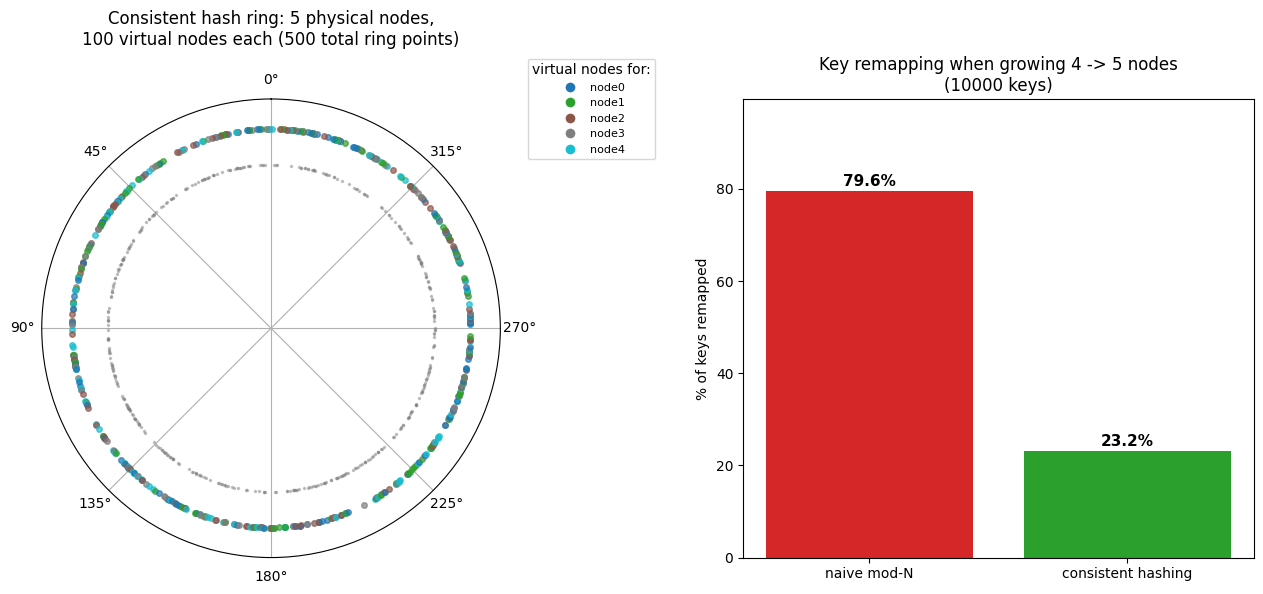

In [16]:
# Visualize the ring as an actual ring (polar plot) colored by owning node,
# plus a bar chart comparing naive vs. consistent-hashing churn.
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(1, 2, 1, projection="polar")
ax2 = fig.add_subplot(1, 2, 2)

# --- Left: the ring itself, colored by owning node, with sample key positions ---
positions = sorted(ring.ring.keys())
node_names = sorted(ring.physical_nodes)
colors = plt.cm.tab10(np.linspace(0, 1, len(node_names)))
color_map = dict(zip(node_names, colors))

theta = np.array(positions) / RING_SIZE * 2 * np.pi
for pos, t in zip(positions, theta):
    owner = ring.ring[pos]
    ax.plot(t, 1.0, marker="o", markersize=4, color=color_map[owner], alpha=0.7)

key_sample = keys[:400]
key_theta = np.array([h(k) % RING_SIZE for k in key_sample]) / RING_SIZE * 2 * np.pi
ax.plot(key_theta, [0.82] * len(key_theta), marker=".", markersize=3, linestyle="none",
        color="gray", alpha=0.4, label="sample keys")

ax.set_ylim(0, 1.15)
ax.set_yticks([])
ax.set_theta_zero_location("N")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=n)
           for n, c in color_map.items()]
ax.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8,
          title="virtual nodes for:")
ax.set_title(f"Consistent hash ring: {len(node_names)} physical nodes,\n"
             f"{ring.vnodes_per_physical} virtual nodes each ({len(positions)} total ring points)",
             pad=20)

bars = ax2.bar(["naive mod-N", "consistent hashing"],
                [pct_moved_naive, pct_moved_ring],
                color=["#d62728", "#2ca02c"])
ax2.set_ylabel("% of keys remapped")
ax2.set_title(f"Key remapping when growing {N_before} -> {N_after} nodes\n({NUM_KEYS} keys)")
for b, pct in zip(bars, [pct_moved_naive, pct_moved_ring]):
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f"{pct:.1f}%",
              ha="center", fontsize=11, fontweight="bold")
ax2.set_ylim(0, max(pct_moved_naive, pct_moved_ring) * 1.25)

plt.tight_layout()
plt.show()

**Takeaway:** consistent hashing turns "add one node" from "reshuffle
almost everything" into "reshuffle roughly $\frac{1}{N+1}$ of the data,
touching only the ring's immediate neighbors of the new node." That's the
mechanism behind how systems like Cassandra, DynamoDB, and most CDN/cache
routing layers add or remove capacity without a full data reshuffle.

## 6. Use cases

- **CAP / AP vs. CP:** Amazon **DynamoDB** and **Cassandra** default to AP
  (always-available, "eventually consistent" reads) because for a shopping
  cart, momentarily stale data is far cheaper than a customer seeing a
  spinning "unavailable" page. **etcd** and **ZooKeeper**, which back
  Kubernetes and many service-discovery systems, choose CP — a
  configuration store returning a stale/wrong answer is worse than briefly
  refusing to answer.
- **Logical clocks:** Amazon's original **Dynamo** paper used vector clocks
  to detect concurrent writes to the same key and surfaced the conflict to
  the application (or a "last write wins" policy) instead of silently
  dropping one write. Distributed tracing systems (e.g. Jaeger, Zipkin)
  use Lamport-style logical ordering to reconstruct a causally consistent
  view of a request's path across microservices.
- **Consensus / Raft:** **etcd**, **Consul**, and **CockroachDB** all use
  Raft (or a close variant) for leader election and replicated-log
  agreement, so that exactly one node is authoritative for writes at a
  time even as nodes crash and restart. **Kafka**'s controller election
  and **Kubernetes**'s leader-election-for-controllers pattern solve the
  identical problem.
- **Consistent hashing:** **Cassandra** and **DynamoDB** partition data
  across nodes with consistent hashing (Dynamo explicitly cites Karger et
  al.). CDN request routing and **memcached** client libraries
  (`libketama`) use it so that adding/removing a cache node doesn't cause
  a stampede of cache misses on every other node.

## 7. Limitations & debates

- **CAP is often over-applied.** CAP is a statement about behavior
  *specifically during a network partition*, not a permanent three-way
  slider you tune at design time. Many real systems are CP *and* highly
  available in the 99.9%+ of the time there's no partition, then briefly
  sacrifice one property only while a partition is actually happening.
  Treating CAP as "pick 2 of 3 forever" (a common oversimplification in
  blog posts and interviews) misrepresents the theorem — see Brewer's own
  2012 retrospective, "CAP Twelve Years Later," where he explicitly pushes
  back on that reading.
- **CAP ignores latency**, which in practice is often the real design
  constraint. The **PACELC** extension (Abadi, 2012) makes this explicit:
  even absent a partition (E), you still trade Latency against Consistency
  (PA/EL, PC/EC, etc.). A system can be "CP" under CAP and still make an
  observable latency-vs-consistency tradeoff every single request.
- **Vector clocks don't scale cleanly.** Their size grows with the number
  of *writers* that have ever touched a key, not just live nodes — Dynamo's
  own retrospective flagged unbounded vector-clock growth ("clock
  clutter") from clients/replicas coming and going as a real operational
  problem, mitigated with pruning heuristics that themselves can discard
  legitimate history.
- **Our Raft simulation is a real leader-election, not a full Raft.**
  We implemented terms, randomized timeouts, majority quorum, and
  heartbeats — the actual safety-critical mechanism — but omitted log
  replication, log-completeness checks during voting (a real Raft voter
  also refuses to vote for a candidate whose log is behind its own), and
  snapshotting. A production Raft (or just using `etcd`/`hashicorp/raft`
  directly, which is what practitioners actually do) needs all of that for
  correctness once you're replicating real data, not just picking a
  leader.
- **Consensus has a hard theoretical ceiling.** The **FLP impossibility
  result** (Fischer, Lynch, Paterson, 1985) proves that in a purely
  *asynchronous* system (no bound on message delay) with even one faulty
  node, **no** deterministic consensus algorithm can guarantee both safety
  and termination in all cases. Raft (and Paxos) sidestep this in practice
  by relying on *partial synchrony* (message delays are usually, though not
  provably, bounded) — randomized timeouts are Raft's concrete way of
  behaving as if the network has practical rather than worst-case timing,
  which is a probabilistic escape hatch, not a violation of FLP's proof.
- **Consistent hashing's load balance depends on virtual-node count.**
  Too few virtual nodes per physical node and the ring is lumpy (some
  nodes get much more than their fair share by chance); too many increases
  memory/lookup overhead. 100-200 per node is a widely used rule of thumb,
  not a formula — production systems tune this empirically.
- **Eventual consistency pushes complexity onto the application.** An AP
  system that lets two nodes diverge (as ours did in Section 2) is only
  "fine" if the application has a real reconciliation strategy (CRDTs,
  application-level merge logic, or accepting last-write-wins data loss).
  "Eventually consistent" is frequently sold as a free lunch; it is a
  deferred cost, not an eliminated one.

## References

- Lamport, L. (1978). *Time, Clocks, and the Ordering of Events in a
  Distributed System.* Communications of the ACM, 21(7).
- Fidge, C. J. (1988) and Mattern, F. (1989). Independent origins of vector
  clocks.
- Gilbert, S., & Lynch, N. (2002). *Brewer's Conjecture and the Feasibility
  of Consistent, Available, Partition-Tolerant Web Services.* ACM SIGACT
  News, 33(2).
- Brewer, E. (2012). *CAP Twelve Years Later: How the "Rules" Have
  Changed.* IEEE Computer, 45(2).
- Abadi, D. (2012). *Consistency Tradeoffs in Modern Distributed Database
  System Design.* IEEE Computer, 45(2). (PACELC)
- Fischer, M., Lynch, N., & Paterson, M. (1985). *Impossibility of
  Distributed Consensus with One Faulty Process.* Journal of the ACM,
  32(2). (FLP impossibility)
- Ongaro, D., & Ousterhout, J. (2014). *In Search of an Understandable
  Consensus Algorithm (Raft).* USENIX ATC. [raft.github.io](https://raft.github.io/)
- Karger, D., Lehman, E., Leighton, T., Panigrahy, R., Levine, M., & Lewin,
  D. (1997). *Consistent Hashing and Random Trees.* ACM STOC.
- DeCandia, G. et al. (2007). *Dynamo: Amazon's Highly Available Key-value
  Store.* SOSP.
- Corbett, J. et al. (2012). *Spanner: Google's Globally-Distributed
  Database.* OSDI.